# Clustering no supervisado (K-Modes) — Saber 11

Este notebook etiqueta cada estudiante con un **cluster socioeconómico** usando un modelo
**no supervisado** sobre las variables categóricas de contexto.

> **Nota metodológica — ¿por qué no "KNN"?**
> KNN (*K-Nearest Neighbors*) es un algoritmo **supervisado**: necesita etiquetas para
> clasificar. Para *crear* etiquetas (clustering) el análogo de la familia "K" es
> **K-Means**, y como nuestros datos son **categóricos** (donde la media aritmética no
> tiene sentido), usamos su variante **K-Modes** (Huang, 1998): reemplaza la media por la
> **moda** de cada variable y la distancia euclídea por la **distancia de Hamming**
> (número de categorías en las que dos registros difieren).

**Fuente de datos:** `v2_datos_limpios.csv` en Kaggle (misma que notebooks 01–06).


## 0. Dependencias

In [1]:
#%pip install -q kmodes umap-learn kagglehub pandas scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
import umap
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
SEED = 42
print('✔  Dependencias cargadas')

/Users/jacobo/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✔  Dependencias cargadas


## 1. Carga

Misma fuente que los notebooks anteriores: `v2_datos_limpios.csv` en Kaggle
(requiere credenciales en `~/.kaggle/kaggle.json`).

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'jacoboayala/datos-icfes-11',
    'v2_datos_limpios.csv',
    pandas_kwargs={'sep': ';', 'low_memory': False}
)
print(f'Filas: {len(df):,}  |  Columnas: {df.shape[1]}')

Filas: 4,821,037  |  Columnas: 28


## 2. Selección de variables para la clusterización

El objetivo del cluster es capturar el **perfil socioeconómico y de contexto escolar** del
estudiante, sin contaminarlo con el resultado académico ni con atributos que queremos usar
*después* para evaluar equidad.

### Variables incluidas (12)

| Grupo | Variable | Por qué entra |
|---|---|---|
| Hogar | `fami_estratovivienda` | Proxy oficial de nivel socioeconómico en Colombia |
| Hogar | `fami_educacionmadre`, `fami_educacionpadre` | Capital cultural del hogar; predictores clásicos de oportunidad educativa |
| Hogar | `fami_tieneinternet`, `fami_tienecomputador` | Acceso a recursos de estudio (brecha digital) |
| Hogar | `fami_tieneautomovil`, `fami_tienelavadora`, `fami_tieneserviciotv` | Bienes durables: complementan al estrato como señal de riqueza material |
| Hogar | `fami_cuartoshogar`, `fami_personashogar` | Capturan hacinamiento (condiciones de estudio en casa) |
| Colegio | `cole_naturaleza` (Oficial / No Oficial) | Eje público–privado del sistema educativo |
| Colegio | `cole_jornada` | La jornada (completa, mañana, tarde, noche, sabatina) refleja tanto recursos del colegio como condición laboral del estudiante |

### Variables excluidas y motivo

| Variable | Motivo de exclusión |
|---|---|
| `punt_global` | Es el **target** del proyecto. Incluirlo haría que los clusters "descubran" el rendimiento (fuga de información); lo usamos solo *a posteriori* para validar |
| `estu_genero`, `cole_area_ubicacion` | **Atributos protegidos** del análisis de equidad. Los dejamos fuera para poder cruzarlos contra los clusters como validación externa, no como insumo |
| `cole_mcpio_ubicacion`, `cole_depto_ubicacion`, `estu_depto_reside` | Alta cardinalidad (hasta 1 017 niveles) sin orden; en Hamming cada municipio sería "igual de distinto" a todos, solo mete ruido |
| `estu_fechanacimiento` | No es categórica (se deriva edad en otros notebooks); la edad no define el perfil socioeconómico |
| `estu_tipodocumento`, `cole_sede_principal` | Administrativas, sin contenido socioeconómico |
| `estu_grado` | Casi constante (≈ todo grado 11) |
| `cole_bilingue`, `cole_calendario`, `cole_genero`, `cole_caracter` | Muy desbalanceadas (p. ej. <2 % bilingüe) o redundantes con `cole_naturaleza`; en Hamming una variable casi constante aporta distancia ≈ 0 y solo añade dimensiones |
| `anio`, `semestre` | Variables temporales, no de perfil |


In [4]:
FEATURES = [
    # Hogar
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_tieneinternet',
    'fami_tienecomputador',
    'fami_tieneautomovil',
    'fami_tienelavadora',
    'fami_tieneserviciotv',
    'fami_cuartoshogar',
    'fami_personashogar',
    # Colegio
    'cole_naturaleza',
    'cole_jornada',
]

# Etiquetas externas para validar (NO entran al modelo)
EXTERNAL = ['punt_global', 'cole_area_ubicacion', 'estu_genero']

n0 = len(df)
df_model = df.dropna(subset=FEATURES).copy()
print(f'Filas sin nulos en las 12 features: {len(df_model):,} de {n0:,} '
      f'({len(df_model)/n0:.1%})')
for c in FEATURES:
    print(f'  {c:25s} niveles={df_model[c].nunique()}')

Filas sin nulos en las 12 features: 4,821,037 de 4,821,037 (100.0%)
  fami_estratovivienda      niveles=7


  fami_educacionmadre       niveles=12


  fami_educacionpadre       niveles=12
  fami_tieneinternet        niveles=2


  fami_tienecomputador      niveles=2
  fami_tieneautomovil       niveles=2


  fami_tienelavadora        niveles=2
  fami_tieneserviciotv      niveles=2


  fami_cuartoshogar         niveles=11
  fami_personashogar        niveles=17


  cole_naturaleza           niveles=2
  cole_jornada              niveles=6


## 3. Muestreo balanceado

Igual que en los notebooks 05 y 06: 10 000 Urbano + 10 000 Rural, para que el perfil rural
(13 % de los datos) no quede ahogado y para mantener el costo computacional de K-Modes
manejable. El etiquetado del dataset completo se hace al final con el modelo ya entrenado.

In [5]:
N_POR_DOMINIO = 10_000

df_sample = (
    df_model.groupby('cole_area_ubicacion', group_keys=False)
            .apply(lambda g: g.sample(n=min(N_POR_DOMINIO, len(g)), random_state=SEED))
            .reset_index(drop=True)
)
X = df_sample[FEATURES].astype(str).to_numpy()
print(f'Muestra: {len(df_sample):,} filas')
print(df_sample['cole_area_ubicacion'].value_counts())

Muestra: 20,000 filas
cole_area_ubicacion
Rural     10000
Urbano    10000
Name: count, dtype: int64


## 4. Elección de k

Dos criterios complementarios, barriendo k = 2 … 8:

1. **Costo de K-Modes** (suma de distancias de Hamming de cada punto a la moda de su
   cluster) → buscamos el "codo".
2. **Silhouette con métrica de Hamming** (sobre una submuestra de 5 000 por costo
   computacional) → buscamos el máximo, penalizando soluciones triviales.

Usamos inicialización **Cao** (determinista, basada en densidad), que evita depender de
re-arranques aleatorios.

In [6]:
K_RANGE = range(2, 9)
costs, sils, models = [], [], {}

# Matriz codificada solo para silhouette (hamming sobre códigos enteros)
X_enc = OrdinalEncoder().fit_transform(X)
rng = np.random.RandomState(SEED)
idx_sil = rng.choice(len(X), size=5_000, replace=False)

for k in K_RANGE:
    km = KModes(n_clusters=k, init='Cao', n_init=1, verbose=0, random_state=SEED)
    labels = km.fit_predict(X)
    sil = silhouette_score(X_enc[idx_sil], labels[idx_sil], metric='hamming')
    costs.append(km.cost_)
    sils.append(sil)
    models[k] = (km, labels)
    print(f'k={k}  costo={km.cost_:>10,.0f}  silhouette(hamming)={sil:.4f}')

k=2  costo=    93,343  silhouette(hamming)=0.2153


k=3  costo=    91,640  silhouette(hamming)=0.1126


k=4  costo=    82,367  silhouette(hamming)=0.1322


k=5  costo=    80,319  silhouette(hamming)=0.1063


k=6  costo=    80,406  silhouette(hamming)=0.0890


k=7  costo=    79,388  silhouette(hamming)=0.0797


k=8  costo=    78,355  silhouette(hamming)=0.0653


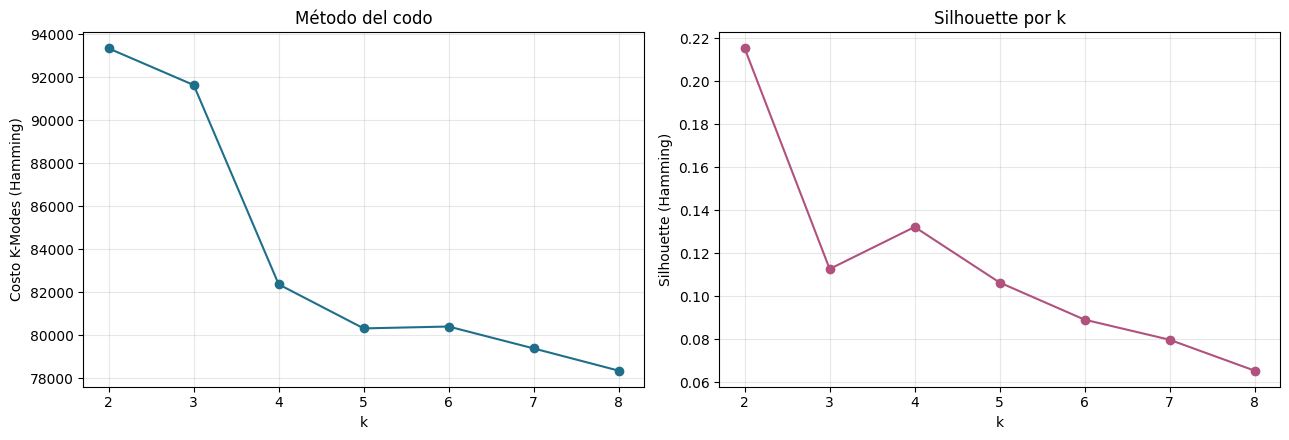

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(K_RANGE), costs, 'o-', color='#1f6f8b')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Costo K-Modes (Hamming)')
axes[0].set_title('Método del codo')

axes[1].plot(list(K_RANGE), sils, 'o-', color='#b1517e')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette (Hamming)')
axes[1].set_title('Silhouette por k')

for ax in axes:
    ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Decisión: **k = 4**

Con los resultados del barrido:

| k | Costo | Δ costo vs k−1 | Silhouette |
|---|---|---|---|
| 2 | 93 343 | — | **0.215** |
| 3 | 91 640 | −1 703 | 0.113 |
| **4** | **82 367** | **−9 273** | **0.132** |
| 5 | 80 319 | −2 048 | 0.106 |
| 6 | 80 406 | +87 | 0.089 |
| 7 | 79 388 | −1 018 | 0.080 |
| 8 | 78 355 | −1 033 | 0.065 |

**Motivos:**

1. **Codo en k = 4.** La caída de costo entre 3 y 4 (−9 273, ~10 %) es por lejos la mayor
   del barrido; a partir de k = 4 la curva se aplana (caídas < 2 100, e incluso sube en
   k = 6). Más clusters ya no compran estructura, solo fragmentan.
2. **Silhouette.** El máximo global está en k = 2, pero esa partición es la división
   trivial *con / sin* acceso a bienes — información que ya tenemos en cada variable
   binaria y que no aporta una segmentación analíticamente útil. **Descartado k = 2, el
   máximo local está exactamente en k = 4** (0.132), coincidiendo con el codo.
3. **Interpretabilidad.** Las modas de los 4 clusters (sección 5) describen perfiles
   socioeconómicos nítidos y monotónicos, sin clusters redundantes.

In [8]:
K_FINAL = 4   # justificación en la celda anterior
km_final, labels_sample = models[K_FINAL]
df_sample['cluster'] = labels_sample

print(f'k escogido: {K_FINAL}')
print(df_sample['cluster'].value_counts().sort_index())

k escogido: 4
cluster
0    5973
1    5938
2    5475
3    2614
Name: count, dtype: int64


## 5. Perfil de los clusters

Las **modas** (centroides categóricos) describen el registro "típico" de cada cluster, y el
heatmap muestra la proporción de cada categoría dentro de cada cluster para las variables
más discriminantes.

In [9]:
centroides = pd.DataFrame(km_final.cluster_centroids_, columns=FEATURES)
centroides.index.name = 'cluster'
centroides.T

cluster,0,1,2,3
fami_estratovivienda,Estrato 1,Estrato 1,Estrato 2,Estrato 3
fami_educacionmadre,Secundaria (Bachillerato) completa,Primaria incompleta,Secundaria (Bachillerato) completa,Educación profesional completa
fami_educacionpadre,Primaria incompleta,Primaria incompleta,Secundaria (Bachillerato) completa,Educación profesional completa
fami_tieneinternet,Si,No,Si,Si
fami_tienecomputador,No,No,Si,Si
fami_tieneautomovil,No,No,No,Si
fami_tienelavadora,Si,No,Si,Si
fami_tieneserviciotv,Si,No,Si,Si
fami_cuartoshogar,Tres,Dos,Dos,Tres
fami_personashogar,3 a 4,5 a 6,3 a 4,3 a 4


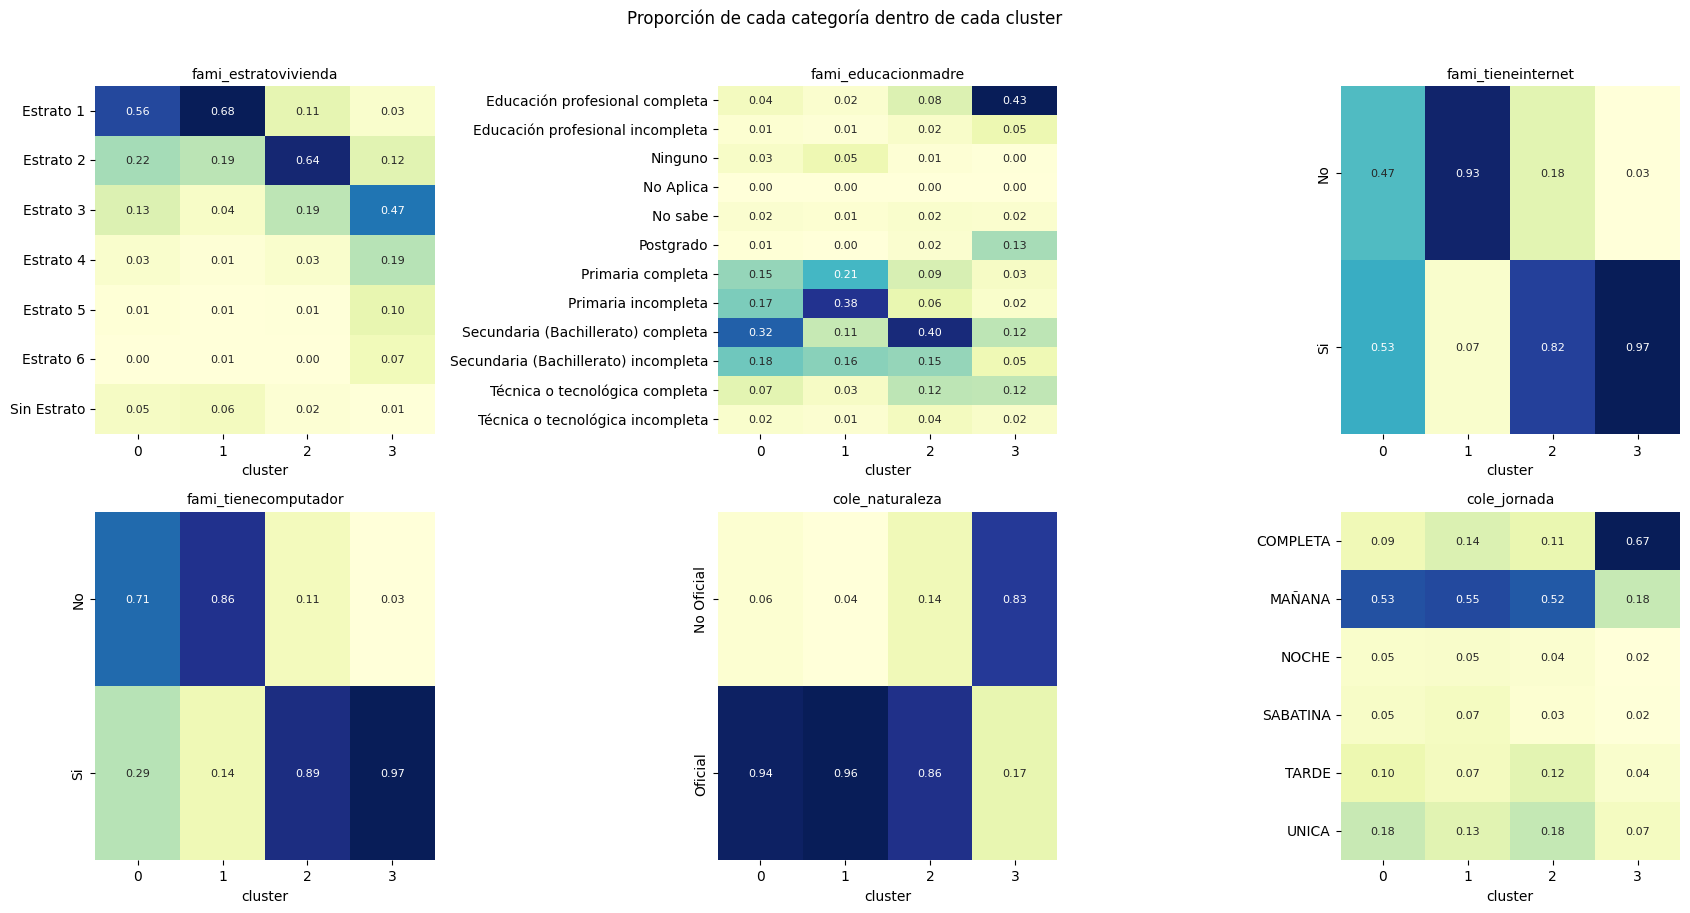

In [10]:
PROFILE_VARS = ['fami_estratovivienda', 'fami_educacionmadre',
                'fami_tieneinternet', 'fami_tienecomputador',
                'cole_naturaleza', 'cole_jornada']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, var in zip(axes.ravel(), PROFILE_VARS):
    ct = pd.crosstab(df_sample[var], df_sample['cluster'], normalize='columns')
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax,
                cbar=False, annot_kws={'size': 8})
    ax.set_title(var, fontsize=10)
    ax.set_xlabel('cluster'); ax.set_ylabel('')
plt.suptitle('Proporción de cada categoría dentro de cada cluster', y=1.01)
plt.tight_layout(); plt.show()

## 6. Verificación visual con UMAP

Proyectamos las 12 variables (one-hot + métrica de **Dice**, apropiada para binarias
dispersas) a 2-D y coloreamos por cluster. Si los clusters son reales, deben verse como
regiones compactas y separadas en el embedding — que se construyó **sin conocer las
etiquetas**.

In [11]:
X_oh = pd.get_dummies(df_sample[FEATURES].astype(str)).to_numpy(dtype=bool)

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='dice', random_state=SEED)
emb = reducer.fit_transform(X_oh)
print('Embedding:', emb.shape)

Embedding: (20000, 2)


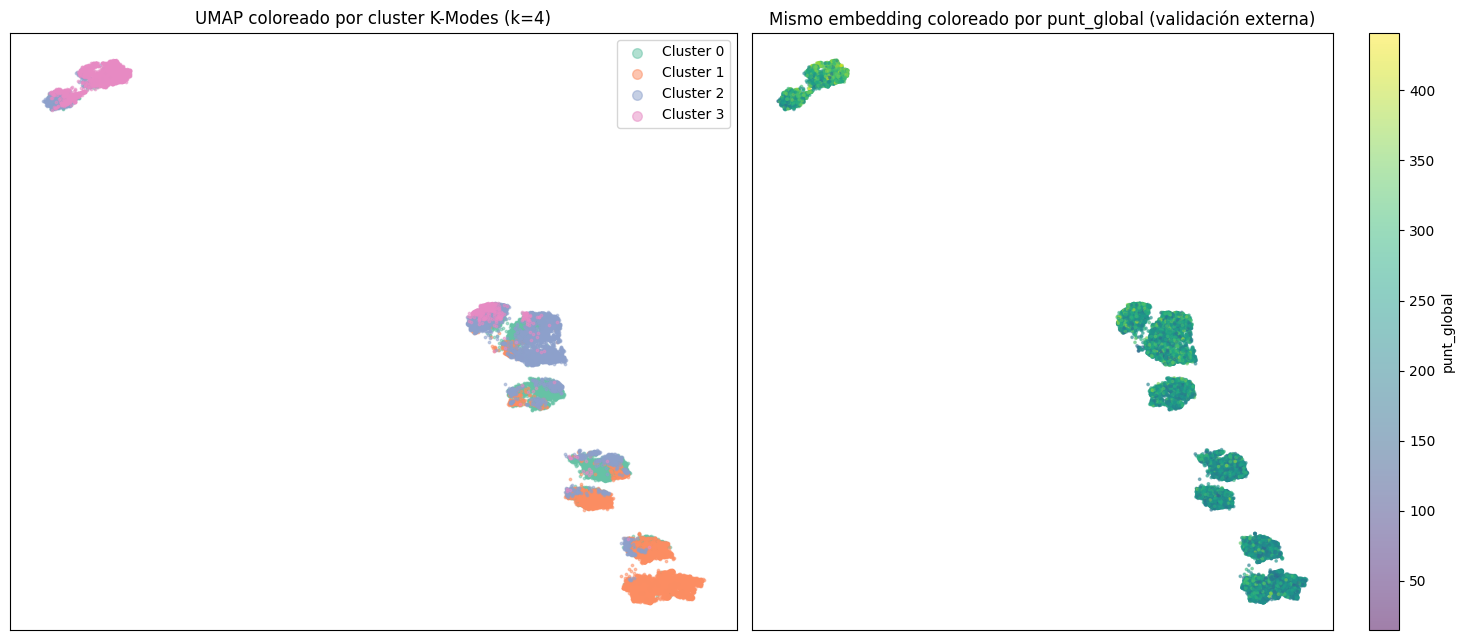

In [12]:
palette = sns.color_palette('Set2', K_FINAL)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for c in range(K_FINAL):
    m = labels_sample == c
    axes[0].scatter(emb[m, 0], emb[m, 1], s=3, alpha=.5,
                    color=palette[c], label=f'Cluster {c}')
axes[0].legend(markerscale=4, frameon=True)
axes[0].set_title(f'UMAP coloreado por cluster K-Modes (k={K_FINAL})')

sc = axes[1].scatter(emb[:, 0], emb[:, 1], s=3, alpha=.5,
                     c=df_sample['punt_global'], cmap='viridis')
plt.colorbar(sc, ax=axes[1], label='punt_global')
axes[1].set_title('Mismo embedding coloreado por punt_global (validación externa)')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Validación externa

`punt_global`, `cole_area_ubicacion` y `estu_genero` **no** entraron al modelo. Si los
clusters capturan un gradiente socioeconómico real, deberían diferenciarse en puntaje y en
composición urbano/rural, y (idealmente) **no** estar definidos por el género.

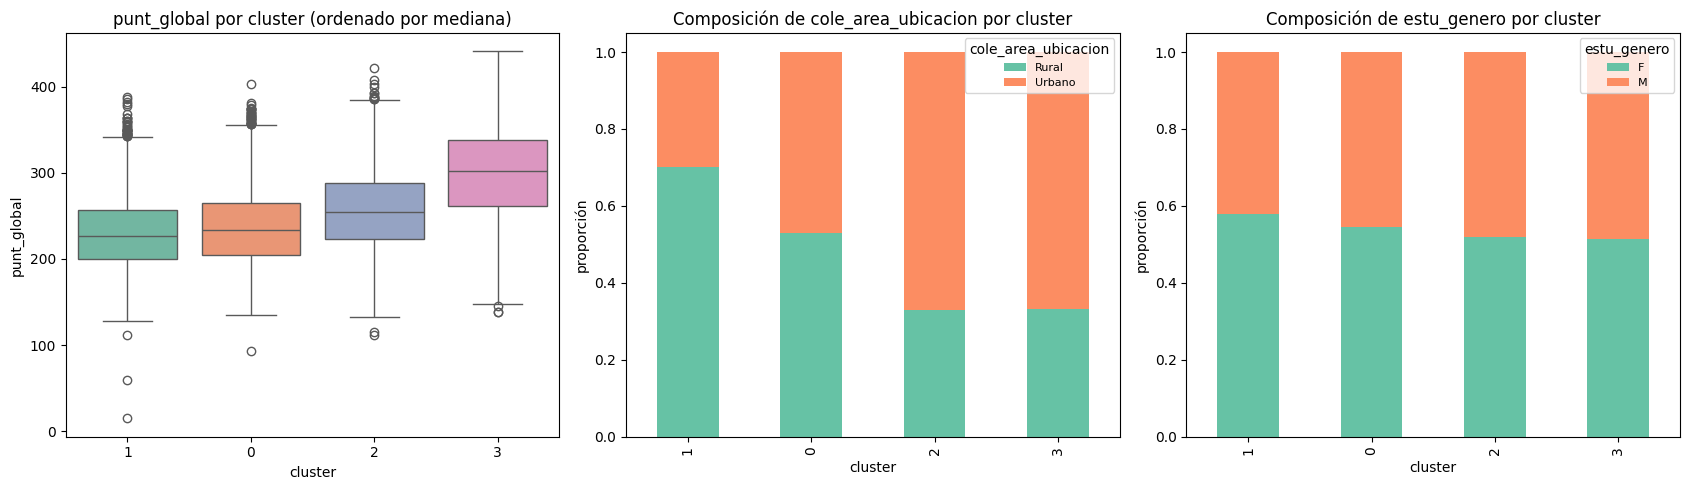

          count   mean   std    min    25%    50%    75%    max
cluster                                                        
0        5973.0  236.5  43.0   93.0  205.0  233.0  265.0  403.0
1        5938.0  230.2  40.2   15.0  200.0  227.0  257.0  388.0
2        5475.0  255.9  46.0  112.0  223.0  255.0  288.0  421.0
3        2614.0  298.3  52.4  138.0  261.0  302.0  338.0  441.0


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

order = (df_sample.groupby('cluster')['punt_global'].median()
                  .sort_values().index.tolist())

sns.boxplot(data=df_sample, x='cluster', y='punt_global', order=order,
            palette='Set2', ax=axes[0])
axes[0].set_title('punt_global por cluster (ordenado por mediana)')

for i, var in enumerate(['cole_area_ubicacion', 'estu_genero'], start=1):
    ct = pd.crosstab(df_sample['cluster'], df_sample[var], normalize='index')
    ct.loc[order].plot(kind='bar', stacked=True, ax=axes[i],
                       color=sns.color_palette('Set2', ct.shape[1]))
    axes[i].set_title(f'Composición de {var} por cluster')
    axes[i].legend(title=var, fontsize=8)
    axes[i].set_ylabel('proporción')

plt.tight_layout(); plt.show()

print(df_sample.groupby('cluster')['punt_global'].describe().round(1))

## 8. Etiquetado del dataset completo

Con el modelo entrenado, asignamos a **cada registro** del dataset (sin nulos en las 12
features) su cluster vía `predict` y guardamos el resultado.

In [14]:
labels_full = km_final.predict(df_model[FEATURES].astype(str).to_numpy())
df_model['cluster'] = labels_full

print(f'Registros etiquetados: {len(df_model):,}')
print(df_model['cluster'].value_counts(normalize=True).sort_index().round(3))

OUT = 'saber11_clusters_kmodes.parquet'
df_model[FEATURES + EXTERNAL + ['cluster']].to_parquet(OUT, index=False)
print(f'💾 Guardado: {OUT}')

Registros etiquetados: 4,821,037
cluster
0    0.283
1    0.214
2    0.339
3    0.164
Name: proportion, dtype: float64


💾 Guardado: saber11_clusters_kmodes.parquet


## 9. Conclusiones

**k escogido: 4** (codo del costo + máximo de silhouette para k ≥ 3 + interpretabilidad).

Los cuatro clusters forman un **gradiente socioeconómico** claro (proporciones sobre los
4.82 M de registros etiquetados):

| Cluster | % | Perfil (modas) | Mediana `punt_global` |
|---|---|---|---|
| 1 | 21.4 % | **Vulnerabilidad alta**: estrato 1, padres con primaria incompleta, sin internet, computador ni bienes durables; colegio oficial | 227 |
| 0 | 28.3 % | **Popular con servicios básicos**: estrato 1, madre con secundaria, internet/lavadora/TV pero sin computador | 233 |
| 2 | 33.9 % | **Medio-bajo conectado**: estrato 2, padres con secundaria completa, internet y computador | 255 |
| 3 | 16.4 % | **Medio-alto**: estrato 3, padres con educación profesional, todos los bienes | 302 |

**Verificación:**

- **UMAP (sección 6):** los clusters ocupan regiones diferenciadas de un embedding
  construido sin conocer las etiquetas, y el gradiente de color de `punt_global` sobre el
  mismo embedding sigue la misma geografía → la estructura es real, no un artefacto del
  algoritmo.
- **Validación externa (sección 7):** el puntaje global —que **no** entró al modelo—
  crece monotónicamente a lo largo del gradiente (mediana 227 → 302, ~75 puntos entre
  extremos). La composición urbano/rural varía fuertemente entre clusters (el cluster 1 es
  mayoritariamente rural; el 3, urbano), mientras que el género se mantiene
  aproximadamente balanceado en todos — como debe ser, dado que el cluster pretende
  capturar contexto socioeconómico y no atributos protegidos.

**Salida:** `saber11_clusters_kmodes.parquet` con las 12 features, las 3 variables
externas y la columna `cluster` para los 4 821 037 registros.